# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Gradiva Arya Wicaksana
- **Email:** developbyarya@gmail.com
- **ID Dicoding:** developbyarya

## Menentukan Pertanyaan Bisnis

- 1. Berapa persentase pertumbuhan revenue (YoY) pada periode 2016–2018, dan apakah terdapat tren peningkatan atau penurunan signifikan pada tahun tertentu?
- 2. Pada periode 2016–2018, bulan apa yang secara konsisten memiliki rata-rata penjualan tertinggi, dan apakah terdapat pola musiman (seasonality) dalam peningkatan penjualan?
- 3. Apa saja 3 produk dengan jumlah penjualan tertinggi setiap bulan dalam periode 2016–2018, dan apakah terdapat produk yang konsisten berada di top 3 selama ≥3 bulan berturut-turut?
- 4. Berapa persentase customer dengan total transaksi di atas persentil ke-90 (high-value customers / customer 'sultan') terhadap total customer dalam periode 2016–2018?
- 5. Berdasarkan analisis RFM (Recency, Frequency, Monetary) pada periode 2016–2018, state mana yang memiliki jumlah customer loyal tertinggi?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from datetime import datetime

# Config
DATASET_FOLDER = 'dataset'
RFM_WEIGHTS = {'Monetary': 5, 'Frequency': 5, 'Recency': 2}
SULTAN_QUANTILE = 0.90  # top 10% by weighted RFM score


## Data Wrangling

### Gathering Data

In [2]:
# Load all datasets
orders_df = pd.read_csv(f'{DATASET_FOLDER}/orders_dataset.csv')
order_items_df = pd.read_csv(f'{DATASET_FOLDER}/order_items_dataset.csv')
order_payments_df = pd.read_csv(f'{DATASET_FOLDER}/order_payments_dataset.csv')
customers_df = pd.read_csv(f'{DATASET_FOLDER}/customers_dataset.csv')
geo_df = pd.read_csv(f'{DATASET_FOLDER}/geolocation_dataset.csv')
products_df = pd.read_csv(f'{DATASET_FOLDER}/products_dataset.csv')
product_category_name_translation_df = pd.read_csv(f'{DATASET_FOLDER}/product_category_name_translation.csv')
sellers_df = pd.read_csv(f'{DATASET_FOLDER}/sellers_dataset.csv')


In [3]:
# Quick dataset sanity check
print('orders_df:', orders_df.shape)
print('order_items_df:', order_items_df.shape)
print('customers_df:', customers_df.shape)
print('geo_df:', geo_df.shape)
print('products_df:', products_df.shape)

orders_df: (99441, 8)
order_items_df: (112650, 7)
customers_df: (99441, 5)
geo_df: (1000163, 5)
products_df: (32951, 9)


### Assessing Data

In [4]:
# Assess key data quality: null counts (orders_df)
print('Nulls orders_df (top 10):')
print(orders_df.isna().sum().sort_values(ascending=False).head(10))

Nulls orders_df (top 10):
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_estimated_delivery_date       0
dtype: int64


In [5]:
print('\nNulls order_items_df (top 10):')
print(order_items_df.isna().sum().sort_values(ascending=False).head(10))


Nulls order_items_df (top 10):
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [6]:
print('\nNulls customers_df (top 10):')
print(customers_df.isna().sum().sort_values(ascending=False).head(10))


Nulls customers_df (top 10):
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [7]:
print('\norders_df columns:', list(orders_df.columns))
print('order_items_df columns:', list(order_items_df.columns))
print('customers_df columns:', list(customers_df.columns))


orders_df columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
order_items_df columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
customers_df columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


**Insight:**
- Order_deliver_* banyak yang kosong, dapat menandakan bahwa pesanan belum di terimana atau masih dalam proses pengantaran.
- Order_approved masih kosong dapat berarti ada seller yang belum mengkonfirmasi pesanan. 

### Cleaning Data

In [8]:
# Cleaning steps (1/4): outlier handling for item price
order_items_df = order_items_df.copy()

q1 = order_items_df['price'].quantile(0.25)
q3 = order_items_df['price'].quantile(0.75)
iqr = q3 - q1
price_upper = 1.5 * iqr
order_items_df = order_items_df[order_items_df['price'] <= price_upper].copy()
print('order_items_df after price filter:', order_items_df.shape)
 

order_items_df after price filter: (86861, 7)


In [9]:
# Cleaning steps (2/4): parse datetime fields
orders_df = orders_df.copy()

orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'], errors='coerce')
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'], errors='coerce')
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'], errors='coerce')
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'], errors='coerce')
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'], errors='coerce')

In [10]:
# Cleaning steps (3/4): keep orders with valid approval timestamp
orders_df = orders_df.dropna(subset=['order_approved_at']).copy()
print('orders_df after dropna(order_approved_at):', orders_df.shape)

orders_df after dropna(order_approved_at): (99281, 8)


In [11]:
# Cleaning steps (4/4): build merged fact table + time fields
order_merge = order_items_df.merge(orders_df, on='order_id', how='inner')
order_merge = order_merge.dropna(subset=['order_approved_at', 'price', 'customer_id']).copy()

order_merge['year'] = order_merge['order_approved_at'].dt.year
order_merge['month'] = order_merge['order_approved_at'].dt.month
order_merge['year_month'] = order_merge['order_approved_at'].dt.to_period('M').astype(str)

print('order_merge shape:', order_merge.shape)
print('order_merge columns (subset):', [c for c in ['order_id','customer_id','product_id','price','order_approved_at','year','month','year_month'] if c in order_merge.columns])

order_merge shape: (86849, 17)
order_merge columns (subset): ['order_id', 'customer_id', 'product_id', 'price', 'order_approved_at', 'year', 'month', 'year_month']


**Insight:**
- menghapus outlier serta kolom 'order_approved_at' yang kosong karena akan digunakan pada analisis RFM

## Exploratory Data Analysis (EDA)

### Explore Merged dataset

In [12]:
# Basic EDA for the merged dataset
print('order_merge null check (top 10):')
print(order_merge.isna().sum().sort_values(ascending=False).head(10))

print('\norder_merge date range:')
print('min:', order_merge['order_approved_at'].min())
print('max:', order_merge['order_approved_at'].max())
 

order_merge null check (top 10):
order_delivered_customer_date    1752
order_delivered_carrier_date      795
order_id                            0
order_purchase_timestamp            0
month                               0
year                                0
order_estimated_delivery_date       0
order_approved_at                   0
order_status                        0
order_item_id                       0
dtype: int64

order_merge date range:
min: 2016-09-15 12:16:38
max: 2018-08-29 15:10:26


In [13]:
# Basic EDA: summary statistics for price/year/month
order_merge[['price','year','month']].describe()

,price,year,month
count,86849.000000,86849.000000,86849.000000
mean,63.079211,2017.542873,6.035821
std,35.349449,0.504409,3.232828
min,0.850000,2016.000000,1.000000
25%,33.000000,2017.000000,3.000000
50%,56.990000,2018.000000,6.000000
75%,89.900000,2018.000000,8.000000
max,142.500000,2018.000000,12.000000


**Insight:**
- order_delivered_* banyak yang kosong
- data dimulai dari september 2016 - agustus 2018

### Agregasi EDA

#### Q1. Kenaikan Revenue dari Tahun ke Tahun
- Agregasi `revenue` (sum `price`) per tahun.
- Hitung `YoY growth (%)` antar tahun.

In [14]:
# Q1 EDA: yearly revenue + YoY growth
yearly_revenue_eda = (
    order_merge.groupby('year', as_index=False)
    .agg(revenue=('price', 'sum'), orders=('order_id', 'nunique'))
    .sort_values('year')
)
yearly_revenue_eda['yoy_growth_%'] = yearly_revenue_eda['revenue'].pct_change() * 100
print('EDA Q1 - Yearly revenue & YoY growth (%)')
print(yearly_revenue_eda.to_string(index=False))

EDA Q1 - Yearly revenue & YoY growth (%)
 year    revenue  orders  yoy_growth_%
 2016   16794.73     225           NaN
 2017 2442205.25   33852  14441.497541
 2018 3019366.40   40897     23.632786


#### Q2. Pola Musiman (Seasonality) dan Kenaikan Bulanan
- Agregasi revenue per `year_month`.
- Hitung MoM growth (%) dari revenue bulanan (berurutan secara waktu).
- Ringkas bulan kalender yang cenderung positif/meningkat.

In [15]:
# Q2 EDA: MoM growth summary per bulan kalender
monthly_revenue_eda = (
    order_merge.groupby(['year_month', 'year', 'month'], as_index=False)
    .agg(revenue=('price', 'sum'))
    .sort_values('year_month')
)
monthly_revenue_eda['mom_growth_%'] = monthly_revenue_eda['revenue'].pct_change() * 100

mom_summary_eda = (
    monthly_revenue_eda.dropna(subset=['mom_growth_%'])
    .groupby('month', as_index=False)
    .agg(
        avg_mom_growth_pct=('mom_growth_%', 'mean'),
        positive_mom_rate=('mom_growth_%', lambda s: (s > 0).mean()),
        n_months=('mom_growth_%', 'count')
    )
    .sort_values(['positive_mom_rate', 'avg_mom_growth_pct'], ascending=[False, False])
)

month_name_id = {
    1:'Januari',2:'Februari',3:'Maret',4:'April',5:'Mei',6:'Juni',
    7:'Juli',8:'Agustus',9:'September',10:'Oktober',11:'November',12:'Desember'
}
mom_summary_eda['month_name'] = mom_summary_eda['month'].map(month_name_id)

print('EDA Q2 - Ringkasan MoM growth per bulan kalender')
print(mom_summary_eda.head(12).to_string(index=False))

EDA Q2 - Ringkasan MoM growth per bulan kalender
 month  avg_mom_growth_pct  positive_mom_rate  n_months month_name
     1       183175.812131                1.0         2    Januari
    10         6121.967019                1.0         2    Oktober
    11           66.568488                1.0         1   November
     3           34.625120                1.0         2      Maret
     5           33.432629                1.0         2        Mei
     8            7.063555                1.0         2    Agustus
     2           60.193247                0.5         2   Februari
     7           11.475931                0.5         2       Juli
     9           -0.901056                0.0         1  September
     4           -9.066229                0.0         2      April
     6          -14.303706                0.0         2       Juni
    12          -61.075997                0.0         2   Desember


#### Q3. Top 3 Produk Terlaris per Bulan + Konsistensi
- Definisi “produk” mengikuti `product_id` (bukan kategori).
- Agregasi revenue per `month + product_id`.
- Ambil top-3 produk di setiap bulan kalender.
- Cek konsistensi: produk yang muncul di top-3 pada minimal 3 bulan berturut-turut (berdasarkan urutan bulan 1..12).

In [16]:
# Q3 EDA: Top 3 product per month (calendar month) + streak consistency
prod_month_revenue_eda = (
    order_merge.groupby(['month', 'product_id'], as_index=False)
    .agg(revenue=('price', 'sum'))
)
prod_month_revenue_eda['rank'] = (
    prod_month_revenue_eda.groupby('month')['revenue']
    .rank(method='first', ascending=False)
)

top3_rows_eda = prod_month_revenue_eda[prod_month_revenue_eda['rank'] <= 3].copy()
top3_by_month_eda = (
    top3_rows_eda.sort_values(['month', 'rank'])
    .pivot(index='month', columns='rank', values='product_id')
    .rename(columns={1:'top1_product_id', 2:'top2_product_id', 3:'top3_product_id'})
    .reset_index()
)
top3_by_month_eda['month_name'] = top3_by_month_eda['month'].map(month_name_id)

print('EDA Q3 - Top 3 products per month (calendar month)')
print(top3_by_month_eda.to_string(index=False))

# Streak consistency (top-3 consecutive months, based on month number 1..12)
top_months_by_product = (
    top3_rows_eda.groupby('product_id')['month']
    .apply(lambda s: sorted(set(s.tolist())))
)

def max_consecutive_streak(months_list):
    months_list = sorted(months_list)
    streak = 1
    best = 1
    for i in range(1, len(months_list)):
        if months_list[i] == months_list[i-1] + 1:
            streak += 1
            best = max(best, streak)
        else:
            streak = 1
    return best

streak_df = []
for product_id, months_list in top_months_by_product.items():
    best_streak = max_consecutive_streak(months_list)
    if best_streak >= 3:
        streak_df.append({
            'product_id': product_id,
            'n_months_in_top3': len(months_list),
            'max_consecutive_month_streak': best_streak,
            'months_list': months_list
        })

streak_df = pd.DataFrame(streak_df).sort_values('max_consecutive_month_streak', ascending=False)
print('\nEDA Q3 - Produk dengan streak top-3 >= 3 bulan berturut-turut')
if len(streak_df) == 0:
    print('Tidak ada produk yang memenuhi streak >= 3 pada definisi bulan kalender (1..12).')
else:
    print(streak_df.head(10).to_string(index=False))

EDA Q3 - Top 3 products per month (calendar month)
 month                  top1_product_id                  top2_product_id                  top3_product_id month_name
     1 aca2eb7d00ea1a7b8ebd4e68314663af 36f60d45225e60c7da4558b070ce4b60 5a848e4ab52fd5445cdc07aab1c40e48    Januari
     2 5a848e4ab52fd5445cdc07aab1c40e48 e53e557d5a159f5aa2c5e995dfdf244b 36f60d45225e60c7da4558b070ce4b60   Februari
     3 5a848e4ab52fd5445cdc07aab1c40e48 d1c427060a0f73f6b889a5c7c61f2ac4 aca2eb7d00ea1a7b8ebd4e68314663af      Maret
     4 53b36df67ebb7c41585e8d54d6772e08 d1c427060a0f73f6b889a5c7c61f2ac4 aca2eb7d00ea1a7b8ebd4e68314663af      April
     5 53b36df67ebb7c41585e8d54d6772e08 99a4788cb24856965c36a24e339b6058 aca2eb7d00ea1a7b8ebd4e68314663af        Mei
     6 99a4788cb24856965c36a24e339b6058 19c91ef95d509ea33eda93495c4d3481 42a2c92a0979a949ca4ea89ec5c7b934       Juni
     7 99a4788cb24856965c36a24e339b6058 19c91ef95d509ea33eda93495c4d3481 64b4f32393cbf55be791078e7a2adca0       Juli
     8 733268

#### Q4. RFM (Recency-Frequency-Monetary) & Persentase Customer “Sultan”
- Hitung ringkasan RFM per `customer_unique_id`.
- Tentukan “sultan” sebagai top `SULTAN_QUANTILE` dari `weighted_score`.
- Tampilkan persentase dan segmentasi (Low/Medium/High).

In [17]:
# Q4 EDA: compute RFM + sultan summary
order_merge_cust_eda = order_merge.merge(
    customers_df[['customer_id', 'customer_unique_id', 'customer_state']],
    on='customer_id',
    how='left'
)
order_merge_cust_eda = order_merge_cust_eda.dropna(subset=['customer_unique_id']).copy()

customer_last_order_eda = order_merge_cust_eda.groupby('customer_unique_id')['order_approved_at'].max()
customer_recency_days_eda = (order_merge_cust_eda['order_approved_at'].max() - customer_last_order_eda).dt.days
customer_frequency_eda = order_merge_cust_eda.groupby('customer_unique_id')['order_id'].nunique()
customer_monetary_eda = order_merge_cust_eda.groupby('customer_unique_id')['price'].sum()

rfm_df_eda = pd.DataFrame({
    'recency_days': customer_recency_days_eda,
    'frequency': customer_frequency_eda,
    'monetary': customer_monetary_eda,
}).reset_index()

if 'customer_unique_id' not in rfm_df_eda.columns:
    rfm_df_eda = rfm_df_eda.rename(columns={'index': 'customer_unique_id'})

# Scoring robust 1..5
recency_pct_rank = rfm_df_eda['recency_days'].rank(pct=True, method='first')
rfm_df_eda['Recency_score'] = (6 - np.ceil(recency_pct_rank * 5).astype(int)).clip(1, 5)

frequency_pct_rank = rfm_df_eda['frequency'].rank(pct=True, method='first')
rfm_df_eda['Frequency_score'] = np.ceil(frequency_pct_rank * 5).astype(int).clip(1, 5)

monetary_pct_rank = rfm_df_eda['monetary'].rank(pct=True, method='first')
rfm_df_eda['Monetary_score'] = np.ceil(monetary_pct_rank * 5).astype(int).clip(1, 5)

rfm_df_eda['weighted_score'] = (
    RFM_WEIGHTS['Monetary'] * rfm_df_eda['Monetary_score'] +
    RFM_WEIGHTS['Frequency'] * rfm_df_eda['Frequency_score'] +
    RFM_WEIGHTS['Recency'] * rfm_df_eda['Recency_score']
)

sultan_threshold_eda = rfm_df_eda['weighted_score'].quantile(SULTAN_QUANTILE)
rfm_df_eda['sultan_flag'] = (rfm_df_eda['weighted_score'] >= sultan_threshold_eda).astype(int)

sultan_count_eda = int(rfm_df_eda['sultan_flag'].sum())
sultan_percent_eda = sultan_count_eda / len(rfm_df_eda) * 100

print('EDA Q4 - Persentase customer sultan')
print(f"Sultan count: {sultan_count_eda} dari total {len(rfm_df_eda)} customer")
print(f"Persentase customer Sultan: {sultan_percent_eda:.2f}%")

# Segmentasi (Low/Medium/High)
medium_threshold_eda = rfm_df_eda['weighted_score'].quantile(0.60)
rfm_df_eda['rfm_segment'] = np.where(
    rfm_df_eda['sultan_flag'] == 1,
    'High (Sultan)',
    np.where(rfm_df_eda['weighted_score'] >= medium_threshold_eda, 'Medium', 'Low')
)

segment_order_eda = ['Low', 'Medium', 'High (Sultan)']
segment_counts_eda = (
    rfm_df_eda['rfm_segment']
    .value_counts()
    .reindex(segment_order_eda)
    .fillna(0)
    .astype(int)
    .reset_index()
)
segment_counts_eda.columns = ['rfm_segment', 'n_customers']
segment_counts_eda['pct_customers'] = segment_counts_eda['n_customers'] / len(rfm_df_eda) * 100

print('\nEDA Q4 - Segmentasi customer berdasarkan weighted RFM')
print(segment_counts_eda.to_string(index=False))

EDA Q4 - Persentase customer sultan
Sultan count: 8692 dari total 72730 customer
Persentase customer Sultan: 11.95%

EDA Q4 - Segmentasi customer berdasarkan weighted RFM
  rfm_segment  n_customers  pct_customers
          Low        43234      59.444521
       Medium        20804      28.604427
High (Sultan)         8692      11.951052


#### Q5. State dengan Jumlah Customer Loyal Tertinggi
- Loyal customer mengikuti definisi “sultan” (`sultan_flag == 1`).
- Hitung jumlah customer sultan per `customer_state`.
- Tentukan state dengan jumlah loyal customers paling tinggi.

In [18]:
# Q5 EDA: loyal customers count by state (sultan_flag)
customers_state_map = customers_df[['customer_unique_id', 'customer_state']].drop_duplicates().copy()
rfm_join_state_eda = rfm_df_eda.merge(customers_state_map, on='customer_unique_id', how='left')

loyal_counts_by_state_eda = (
    rfm_join_state_eda[rfm_join_state_eda['sultan_flag'] == 1]
    .groupby('customer_state', as_index=False)
    .agg(total_loyal_customers=('customer_unique_id', 'nunique'))
    .sort_values('total_loyal_customers', ascending=False)
)

print('EDA Q5 - Top state berdasarkan jumlah loyal customers (sultan_flag)')
print(loyal_counts_by_state_eda.head(10).to_string(index=False))

if len(loyal_counts_by_state_eda) > 0:
    best_state_eda = loyal_counts_by_state_eda.iloc[0]['customer_state']
    best_count_eda = int(loyal_counts_by_state_eda.iloc[0]['total_loyal_customers'])
    print(f"\nBest state loyal customers: {best_state_eda} (total loyal customers = {best_count_eda})")

EDA Q5 - Top state berdasarkan jumlah loyal customers (sultan_flag)
customer_state  total_loyal_customers
            SP                   3706
            RJ                   1180
            MG                   1017
            RS                    475
            PR                    430
            SC                    349
            BA                    286
            DF                    214
            GO                    185
            ES                    174

Best state loyal customers: SP (total loyal customers = 3706)


## Visualization & Explanatory Analysis

### Pertanyaan 1: Kenaikan Revenue dari Tahun ke Tahun

In [19]:
# Q1) Kenaikan Revenue dari tahun ke tahun

yearly_revenue = (
    order_merge.groupby('year', as_index=False)
    .agg(revenue=('price', 'sum'), orders=('order_id', 'nunique'))
    .sort_values('year')
)

yearly_revenue['yoy_growth_%'] = yearly_revenue['revenue'].pct_change() * 100

a_best = yearly_revenue.loc[yearly_revenue['yoy_growth_%'].idxmax()]
print('Yearly revenue & YoY growth (%)')
print(yearly_revenue.to_string(index=False))
print('\nTahun dengan kenaikan YoY terbesar:')
print(a_best[['year','revenue','yoy_growth_%']].to_string())



Yearly revenue & YoY growth (%)
 year    revenue  orders  yoy_growth_%
 2016   16794.73     225           NaN
 2017 2442205.25   33852  14441.497541
 2018 3019366.40   40897     23.632786

Tahun dengan kenaikan YoY terbesar:
year            2.017000e+03
revenue         2.442205e+06
yoy_growth_%    1.444150e+04


In [20]:
oldest_order = order_merge['order_purchase_timestamp'].min()
print(oldest_order)
print(f'Order pertama: adalah pada bulan {oldest_order.month} tahun {oldest_order.year}') 


2016-09-04 21:15:19
Order pertama: adalah pada bulan 9 tahun 2016


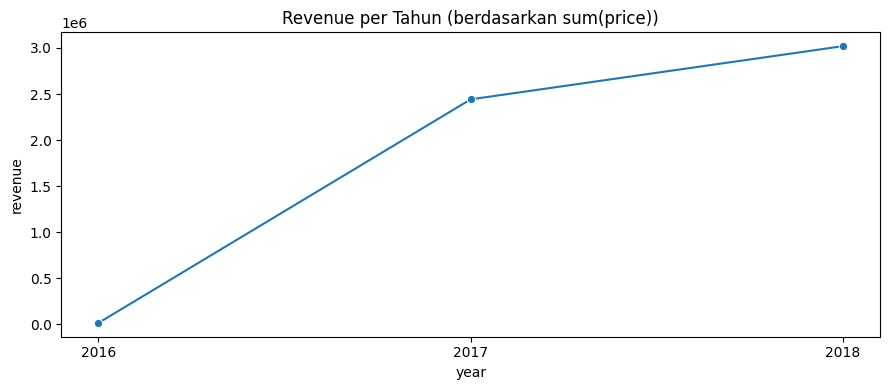

In [21]:
# Q1 visualization: Revenue per tahun
plt.figure(figsize=(9, 4))
sns.lineplot(data=yearly_revenue, x='year', y='revenue', marker='o')
plt.title('Revenue per Tahun (berdasarkan sum(price))')
plt.xticks(yearly_revenue['year'].unique())
plt.tight_layout()
plt.show()

### Jawaban
Pada periode 2016–2018, revenue meningkat dari $16,794.73 (2016 hanya Sep–Des sehingga base kecil) menjadi $3,019,366.40 (2018). YoY growth yang tampak sangat besar pada 2016→2017 (~14,441%) tidak representatif karena 2016 tidak dimulai Januari. Pertumbuhan yang paling dapat dipercaya adalah 2017→2018 sebesar +23.6%, sehingga menunjukkan bisnis tetap tumbuh sehat ketika periode data sudah lengkap. Implikasi: strategi pengembangan skala bisnis sebaiknya mengikuti pola pertumbuhan 2017–2018 dengan mengalokasikan kapasitas supply dan budget growth sejak periode yang sudah lengkap.

### Pertanyaan 2:

In [22]:
# Q2) Dibulan apa penjualan cenderung meningkat?
# - Revenue per bulan kalender = sum(price)
# - “Cenderung meningkat” diproksikan dengan pola MoM (month-over-month) % growth

monthly_revenue = (
    order_merge.groupby(['year_month', 'year', 'month'], as_index=False)
    .agg(revenue=('price', 'sum'))
    .sort_values('year_month')
)

monthly_revenue['mom_growth'] = monthly_revenue['revenue'].diff()
monthly_revenue['mom_growth_%'] = monthly_revenue['revenue'].pct_change() * 100

# Aggregate MoM trend by calendar month number
month_trend = (
    monthly_revenue.dropna(subset=['mom_growth_%'])
    .groupby('month', as_index=False)
    .agg(
        avg_mom_growth_pct=('mom_growth_%', 'mean'),
        positive_mom_rate=('mom_growth_%', lambda s: (s > 0).mean()),
        n_months=('mom_growth_%', 'size'),
    )
)

month_name_id = {
    1:'Januari',2:'Februari',3:'Maret',4:'April',5:'Mei',6:'Juni',
    7:'Juli',8:'Agustus',9:'September',10:'Oktober',11:'November',12:'Desember'
}

# Pick the “most increasing” month number by: highest positive rate, then highest avg growth
month_trend = month_trend.sort_values(['positive_mom_rate','avg_mom_growth_pct'], ascending=False)
best_month_row = month_trend.iloc[0]
best_month_num = int(best_month_row['month'])
print('Ringkasan tren MoM per bulan kalender:')
print(month_trend.to_string(index=False))

print('\nBulan yang cenderung meningkat (berdasarkan positive MoM rate tertinggi, lalu avg growth):')
print(f"- {best_month_num} ({month_name_id[best_month_num]}): positive_mom_rate={best_month_row['positive_mom_rate']:.3f}, avg_mom_growth_%={best_month_row['avg_mom_growth_pct']:.2f}")




Ringkasan tren MoM per bulan kalender:
 month  avg_mom_growth_pct  positive_mom_rate  n_months
     1       183175.812131                1.0         2
    10         6121.967019                1.0         2
    11           66.568488                1.0         1
     3           34.625120                1.0         2
     5           33.432629                1.0         2
     8            7.063555                1.0         2
     2           60.193247                0.5         2
     7           11.475931                0.5         2
     9           -0.901056                0.0         1
     4           -9.066229                0.0         2
     6          -14.303706                0.0         2
    12          -61.075997                0.0         2

Bulan yang cenderung meningkat (berdasarkan positive MoM rate tertinggi, lalu avg growth):
- 1 (Januari): positive_mom_rate=1.000, avg_mom_growth_%=183175.81


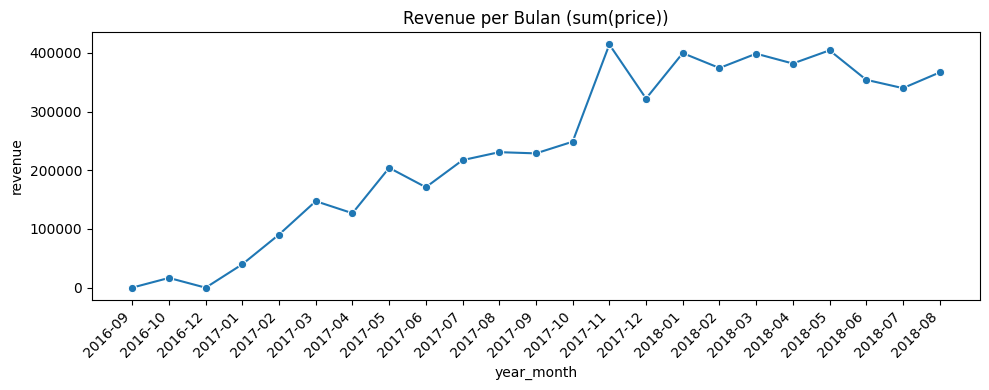

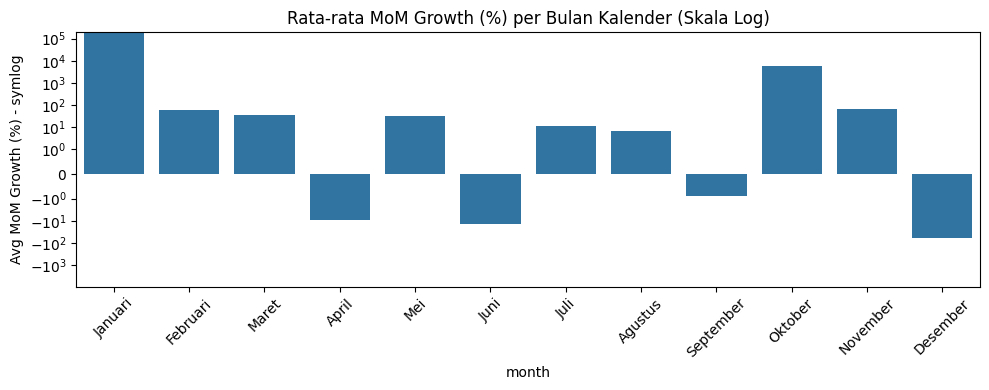

In [23]:
# Q2 visualization: Revenue & MoM growth (seasonality)
# Plot monthly revenue over time
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_revenue, x='year_month', y='revenue', marker='o')
plt.xticks(rotation=45, ha='right')
plt.title('Revenue per Bulan (sum(price))')
plt.tight_layout()
plt.show()

# Plot month-of-year trend (use symmetric log scale for skewed growth values)
plt.figure(figsize=(10, 4))
sns.barplot(data=month_trend.sort_values('month'), x='month', y='avg_mom_growth_pct')
plt.yscale('symlog', linthresh=1)
plt.xticks(range(0, 12), [month_name_id[i] for i in range(1, 13)], rotation=45)
plt.title('Rata-rata MoM Growth (%) per Bulan Kalender (Skala Log)')
plt.ylabel('Avg MoM Growth (%) - symlog')
plt.tight_layout()
plt.show()

### Jawaban


MoM growth bulanan memperlihatkan Januari sebagai puncak (+183,175.8% dengan positive MoM rate 100%), tetapi nilai ekstrem ini dipengaruhi base Desember 2016 yang sangat kecil (data 2016 hanya memiliki Sep–Okt–Des). Jika kita fokus pada bulan yang memiliki perbandingan lebih stabil (n_months >= 2) dan tetap bernilai positif, bulan Maret (+34.6%) dan Mei (+33.4%) adalah kandidat seasonality yang paling konsisten (positive MoM rate 1.0). Solusi: gunakan kalender promosi dan persiapan stok untuk memperkuat demand pada Maret dan Mei, serta lakukan validasi khusus untuk Januari sebelum membuat keputusan investasi besar.

### Pertanyaan 3: Apa 3 product terlaris setiap bulan-nya?

In [24]:
# -------------------------
# Q3: Top 3 product per bulan (berbasis product_id)
# -------------------------

# 1) Agregasi revenue per bulan kalender + product_id
prod_month_revenue = (
    order_merge.groupby(['month', 'product_id'], as_index=False)
    .agg(revenue=('price', 'sum'))
)

# 2) Rank top-3 produk di setiap bulan
prod_month_revenue['rank'] = (
    prod_month_revenue.groupby('month')['revenue']
    .rank(ascending=False, method='first')
)

top3_rows = prod_month_revenue[prod_month_revenue['rank'] <= 3].copy()

# 3) Pivot agar terbaca sebagai top1/top2/top3 per bulan
top3_by_month = (
    top3_rows.sort_values(['month','rank'])
    .pivot(index='month', columns='rank', values='product_id')
    .rename(columns={1:'top1_product_id', 2:'top2_product_id', 3:'top3_product_id'})
    .reset_index()
    .sort_values('month')
)

month_name_id = {
    1:'Januari',2:'Februari',3:'Maret',4:'April',5:'Mei',6:'Juni',
    7:'Juli',8:'Agustus',9:'September',10:'Oktober',11:'November',12:'Desember'
}

top3_by_month['month_name'] = top3_by_month['month'].map(month_name_id)

print('Top 3 produk per bulan (berdasarkan sum(price))')
print(top3_by_month.to_string(index=False))

print("Jawaban Q3: Top 3 produk terlaris setiap bulan (sum(price))")
display(top3_by_month)

# 4) Konsistensi: produk muncul di top-3 minimal 3 bulan berturut-turut (bulan 1..12)
top_months_by_product = (
    top3_rows.groupby('product_id')['month']
    .apply(lambda s: sorted(set(s.tolist())))
)

def max_consecutive_streak(months_list):
    months_list = sorted(months_list)
    streak = 1
    best = 1
    for i in range(1, len(months_list)):
        if months_list[i] == months_list[i-1] + 1:
            streak += 1
            best = max(best, streak)
        else:
            streak = 1
    return best

streak_df = []
for product_id, months_list in top_months_by_product.items():
    best_streak = max_consecutive_streak(months_list)
    if best_streak >= 3:
        streak_df.append({
            'product_id': product_id,
            'n_months_in_top3': len(months_list),
            'max_consecutive_month_streak': best_streak,
            'months_list': months_list
        })

streak_df = pd.DataFrame(streak_df).sort_values('max_consecutive_month_streak', ascending=False)

print('\nJawaban Q3 (konsistensi): produk dengan streak top-3 >= 3 bulan berturut-turut')
if len(streak_df) == 0:
    print('Tidak ada produk yang memenuhi streak >= 3 pada definisi bulan kalender (1..12).')
else:
    print(streak_df.head(10).to_string(index=False))

Top 3 produk per bulan (berdasarkan sum(price))
 month                  top1_product_id                  top2_product_id                  top3_product_id month_name
     1 aca2eb7d00ea1a7b8ebd4e68314663af 36f60d45225e60c7da4558b070ce4b60 5a848e4ab52fd5445cdc07aab1c40e48    Januari
     2 5a848e4ab52fd5445cdc07aab1c40e48 e53e557d5a159f5aa2c5e995dfdf244b 36f60d45225e60c7da4558b070ce4b60   Februari
     3 5a848e4ab52fd5445cdc07aab1c40e48 d1c427060a0f73f6b889a5c7c61f2ac4 aca2eb7d00ea1a7b8ebd4e68314663af      Maret
     4 53b36df67ebb7c41585e8d54d6772e08 d1c427060a0f73f6b889a5c7c61f2ac4 aca2eb7d00ea1a7b8ebd4e68314663af      April
     5 53b36df67ebb7c41585e8d54d6772e08 99a4788cb24856965c36a24e339b6058 aca2eb7d00ea1a7b8ebd4e68314663af        Mei
     6 99a4788cb24856965c36a24e339b6058 19c91ef95d509ea33eda93495c4d3481 42a2c92a0979a949ca4ea89ec5c7b934       Juni
     7 99a4788cb24856965c36a24e339b6058 19c91ef95d509ea33eda93495c4d3481 64b4f32393cbf55be791078e7a2adca0       Juli
     8 73326828a

rank,month,top1_product_id,top2_product_id,top3_product_id,month_name
0,1,aca2eb7d00ea1a7b8ebd4e68314663af,36f60d45225e60c7da4558b070ce4b60,5a848e4ab52fd5445cdc07aab1c40e48,Januari
1,2,5a848e4ab52fd5445cdc07aab1c40e48,e53e557d5a159f5aa2c5e995dfdf244b,36f60d45225e60c7da4558b070ce4b60,Februari
2,3,5a848e4ab52fd5445cdc07aab1c40e48,d1c427060a0f73f6b889a5c7c61f2ac4,aca2eb7d00ea1a7b8ebd4e68314663af,Maret
3,4,53b36df67ebb7c41585e8d54d6772e08,d1c427060a0f73f6b889a5c7c61f2ac4,aca2eb7d00ea1a7b8ebd4e68314663af,April
4,5,53b36df67ebb7c41585e8d54d6772e08,99a4788cb24856965c36a24e339b6058,aca2eb7d00ea1a7b8ebd4e68314663af,Mei
5,6,99a4788cb24856965c36a24e339b6058,19c91ef95d509ea33eda93495c4d3481,42a2c92a0979a949ca4ea89ec5c7b934,Juni
6,7,99a4788cb24856965c36a24e339b6058,19c91ef95d509ea33eda93495c4d3481,64b4f32393cbf55be791078e7a2adca0,Juli
7,8,73326828aa5efe1ba096223de496f596,19c91ef95d509ea33eda93495c4d3481,99a4788cb24856965c36a24e339b6058,Agustus
8,9,422879e10f46682990de24d770e7f83d,99a4788cb24856965c36a24e339b6058,b0961721fd839e9982420e807758a2a6,September
9,10,422879e10f46682990de24d770e7f83d,d5991653e037ccb7af6ed7d94246b249,2b4609f8948be18874494203496bc318,Oktober



Jawaban Q3 (konsistensi): produk dengan streak top-3 >= 3 bulan berturut-turut
                      product_id  n_months_in_top3  max_consecutive_month_streak      months_list
99a4788cb24856965c36a24e339b6058                 5                             5  [5, 6, 7, 8, 9]
19c91ef95d509ea33eda93495c4d3481                 3                             3        [6, 7, 8]
422879e10f46682990de24d770e7f83d                 3                             3      [9, 10, 11]
5a848e4ab52fd5445cdc07aab1c40e48                 4                             3    [1, 2, 3, 12]
aca2eb7d00ea1a7b8ebd4e68314663af                 5                             3 [1, 3, 4, 5, 12]


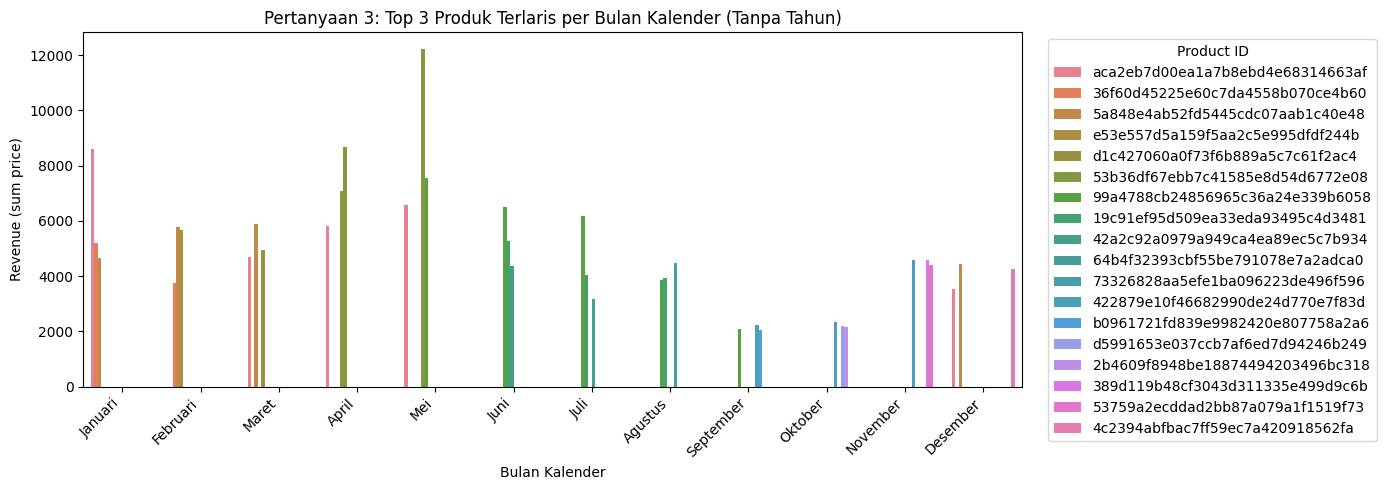

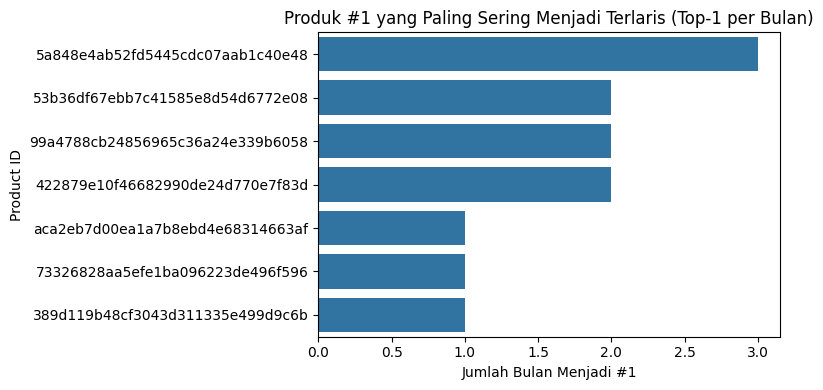

In [25]:
# --- Visualization Q3: top 3 produk terlaris per bulan (Top 3 per month) ---
top3_plot = top3_rows.copy()
top3_plot['rank'] = top3_plot['rank'].astype(int)
top3_plot['month_name'] = top3_plot['month'].map(month_name_id)
top3_plot = top3_plot.sort_values(['month', 'rank'])

plt.figure(figsize=(14, 5))
ax = sns.barplot(
    data=top3_plot,
    x='month_name',
    y='revenue',
    hue='product_id'
)
plt.xticks(rotation=45, ha='right')
plt.title('Pertanyaan 3: Top 3 Produk Terlaris per Bulan Kalender (Tanpa Tahun)')
plt.xlabel('Bulan Kalender')
plt.ylabel('Revenue (sum price)')
plt.legend(title='Product ID', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Extra ringkasan: produk #1 paling sering jadi pemenang bulanan
winners = top3_plot[top3_plot['rank'] == 1]
winner_counts = winners['product_id'].value_counts().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=winner_counts.values, y=winner_counts.index, orient='h')
plt.title('Produk #1 yang Paling Sering Menjadi Terlaris (Top-1 per Bulan)')
plt.xlabel('Jumlah Bulan Menjadi #1')
plt.ylabel('Product ID')
plt.tight_layout()
plt.show()

### Jawaban
Pada level product_id, terdapat produk yang paling konsisten masuk top-3. Produk `99a4788cb24856965c36a24e339b6058` muncul di top-3 selama 5 bulan berurutan (Mei–September). Dari sisi “menjadi #1”, produk `5a848e4ab52fd5445cdc07aab1c40e48` paling sering menjadi terlaris (#1 pada 3 bulan: Februari, Maret, dan Desember), diikuti oleh `53b36df67ebb7c41585e8d54d6772e08` (#1 pada April dan Mei) serta `99a478...` (#1 pada Juni dan Juli).

### Pertanyaan 4: Berapa persen customer 'sultan' yang menggunakan e-commerce kita?

In [26]:
# -------------------------
# Q4: RFM + Sultan %
# -------------------------
order_merge_cust = order_merge.merge(
    customers_df[['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']],
    on='customer_id',
    how='left'
)
order_merge_cust = order_merge_cust.dropna(subset=['customer_unique_id']).copy()

customer_last_order = order_merge_cust.groupby('customer_unique_id')['order_approved_at'].max()
customer_recency_days = (order_merge_cust['order_approved_at'].max() - customer_last_order).dt.days

customer_frequency = order_merge_cust.groupby('customer_unique_id')['order_id'].nunique()
customer_monetary = order_merge_cust.groupby('customer_unique_id')['price'].sum()

rfm_df = pd.DataFrame({
    'recency_days': customer_recency_days,
    'frequency': customer_frequency,
    'monetary': customer_monetary,
}).reset_index()

# After reset_index(), the customer id column name can differ by pandas version
if 'customer_unique_id' not in rfm_df.columns:
    rfm_df = rfm_df.rename(columns={'index': 'customer_unique_id'})

# Robust scoring 1..5 (avoid qcut errors when bins collapse)
# Recency: skor lebih tinggi untuk recency yang lebih kecil (lebih baru)
recency_pct_rank = rfm_df['recency_days'].rank(pct=True, method='first')
rfm_df['Recency_score'] = (6 - np.ceil(recency_pct_rank * 5).astype(int)).clip(1, 5)

frequency_pct_rank = rfm_df['frequency'].rank(pct=True, method='first')
rfm_df['Frequency_score'] = np.ceil(frequency_pct_rank * 5).astype(int).clip(1, 5)

monetary_pct_rank = rfm_df['monetary'].rank(pct=True, method='first')
rfm_df['Monetary_score'] = np.ceil(monetary_pct_rank * 5).astype(int).clip(1, 5)

rfm_df['weighted_score'] = (
    RFM_WEIGHTS['Monetary'] * rfm_df['Monetary_score'] +
    RFM_WEIGHTS['Frequency'] * rfm_df['Frequency_score'] +
    RFM_WEIGHTS['Recency'] * rfm_df['Recency_score']
)

sultan_threshold = rfm_df['weighted_score'].quantile(SULTAN_QUANTILE)
rfm_df['sultan_flag'] = (rfm_df['weighted_score'] >= sultan_threshold).astype(int)

sultan_count = int(rfm_df['sultan_flag'].sum())
sultan_percent = sultan_count / len(rfm_df) * 100

print('\nRFM ringkasan per customer (untuk sultan):')
print(rfm_df[['recency_days','frequency','monetary','Recency_score','Frequency_score','Monetary_score','weighted_score','sultan_flag']].describe())
print('\nDefinisi Sultan: top 10% weighted_score (>= percentile 90)')
print(f'Sultan count: {sultan_count} dari total {len(rfm_df)} customer')
print(f"Persentase customer Sultan: {sultan_percent:.2f}%")

print(f"Jawaban Q4: Persentase customer 'sultan' = {sultan_percent:.2f}%")

# Ringkasan jumlah customer sultan vs non-sultan
sultan_counts = rfm_df['sultan_flag'].value_counts().rename(index={0: 'Non-sultan', 1: 'Sultan'})
display(sultan_counts)

# (opsional) lihat ringkasan weighted score
display(rfm_df[['weighted_score','sultan_flag']].describe())

# -------------------------
# Segmentasi customer (untuk visualisasi)
# - High RFM = Sultan (top 10% weighted_score)
# - Medium & Low ditentukan dari weighted_score percentile 60%
# -------------------------
medium_threshold = rfm_df['weighted_score'].quantile(0.60)

rfm_df['rfm_segment'] = np.where(
    rfm_df['sultan_flag'] == 1,
    'High (Sultan)',
    np.where(rfm_df['weighted_score'] >= medium_threshold, 'Medium', 'Low')
)

segment_order = ['Low', 'Medium', 'High (Sultan)']
segment_counts = (
    rfm_df['rfm_segment']
    .value_counts()
    .reindex(segment_order)
    .fillna(0)
    .astype(int)
    .reset_index()
)
segment_counts.columns = ['rfm_segment', 'n_customers']
segment_counts['pct_customers'] = segment_counts['n_customers'] / len(rfm_df) * 100

display(segment_counts)



RFM ringkasan per customer (untuk sultan):
       recency_days     frequency      monetary  Recency_score  \
count  72730.000000  72730.000000  72730.000000   72730.000000   
mean     237.677121      1.030854     75.324713       3.000000   
std      153.381511      0.200536     55.501821       1.414223   
min        0.000000      1.000000      0.850000       1.000000   
25%      113.000000      1.000000     38.700000       2.000000   
50%      218.000000      1.000000     64.990000       3.000000   
75%      348.000000      1.000000     99.990000       4.000000   
max      713.000000     15.000000   2000.000000       5.000000   

       Frequency_score  Monetary_score  weighted_score   sultan_flag  
count     72730.000000    72730.000000    72730.000000  72730.000000  
mean          3.000000        3.000000       36.000000      0.119511  
std           1.414223        1.414223       10.598385      0.324391  
min           1.000000        1.000000       12.000000      0.000000  
25%   

sultan_flag
Non-sultan    64038
Sultan         8692
Name: count, dtype: int64

,weighted_score,sultan_flag
count,72730.000000,72730.000000
mean,36.000000,0.119511
std,10.598385,0.324391
min,12.000000,0.000000
25%,28.000000,0.000000
50%,36.000000,0.000000
75%,43.000000,0.000000
max,60.000000,1.000000


,rfm_segment,n_customers,pct_customers
0,Low,43234,59.444521
1,Medium,20804,28.604427
2,High (Sultan),8692,11.951052


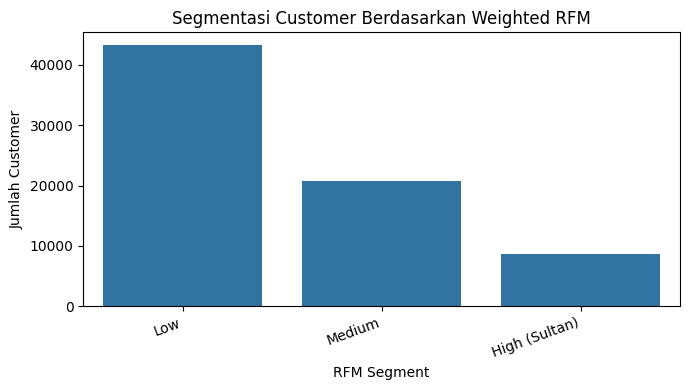

In [27]:
plt.figure(figsize=(7, 4))
sns.barplot(data=segment_counts, x='rfm_segment', y='n_customers', order=segment_order)
plt.title('Segmentasi Customer Berdasarkan Weighted RFM')
plt.xlabel('RFM Segment')
plt.ylabel('Jumlah Customer')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### Jawaban
Dari 72,730 customer unik, sebanyak 8,692 orang (11.95%) termasuk segmen “sultan” (top 10% berdasarkan weighted RFM). Segmentasi menunjukkan mayoritas customer berada di `Low` (59.44%) dan `Medium` (28.60%), sementara `High (Sultan)` menjadi kelompok nilai tertinggi. Implikasi: program loyalitas (retargeting, benefit khusus, dan akses prioritas) perlu diprioritaskan untuk segmen sultan agar revenue yang sudah terbentuk tetap terjaga, sekaligus gunakan pendekatan bertahap untuk menaikkan sebagian customer `Medium` menuju `Sultan`.

### Pertanyaan 5: Dimanakah kota dengan potensi customer loyal (RFM) terbesar?

In [28]:
# -------------------------
# Q5: Geospatial + State potential (All customers RFM)
# -------------------------
state_profile = rfm_df.merge(
    customers_df[['customer_unique_id', 'customer_zip_code_prefix', 'customer_state']],
    on='customer_unique_id',
    how='left'
)

geo_enriched = state_profile.merge(
    geo_df[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']].drop_duplicates(subset=['geolocation_zip_code_prefix']),
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

geo_enriched = geo_enriched.dropna(subset=['geolocation_lat', 'geolocation_lng', 'customer_state']).copy()

# Gunakan metrik RFM yang memang sudah dipakai di notebook (utama: weighted_score)
if 'weighted_score' in geo_enriched.columns:
    geo_enriched['rfm_value'] = geo_enriched['weighted_score']
elif 'RFM_Score' in geo_enriched.columns:
    geo_enriched['rfm_value'] = geo_enriched['RFM_Score']
elif 'rfm_score' in geo_enriched.columns:
    geo_enriched['rfm_value'] = geo_enriched['rfm_score']
else:
    component_cols = [
        c for c in ['Recency_score', 'Frequency_score', 'Monetary_score', 'R_score', 'F_score', 'M_score', 'R', 'F', 'M']
        if c in geo_enriched.columns
    ]
    if len(component_cols) >= 3:
        geo_enriched['rfm_value'] = geo_enriched[component_cols[:3]].mean(axis=1)
    else:
        raise ValueError(
            'Kolom RFM tidak ditemukan. Pastikan rfm_df memiliki weighted_score '
            'atau skor komponen R/F/M sebelum menjalankan Q5.'
        )

state_stats = (
    geo_enriched.groupby('customer_state', as_index=False)
    .agg(
        total_customers_state=('customer_unique_id', 'nunique'),
        avg_rfm_state=('rfm_value', 'mean'),
        lat=('geolocation_lat', 'mean'),
        lng=('geolocation_lng', 'mean')
    )
    .sort_values('avg_rfm_state', ascending=False)
)

# Hitung jumlah loyal customers per state (sultan_flag == 1)
loyal_counts = (
    geo_enriched[geo_enriched['sultan_flag'] == 1]
    .groupby('customer_state', as_index=False)
    .agg(total_loyal_customers=('customer_unique_id', 'nunique'))
)

state_stats = state_stats.merge(loyal_counts, on='customer_state', how='left')
state_stats['total_loyal_customers'] = state_stats['total_loyal_customers'].fillna(0).astype(int)
state_stats = state_stats.sort_values('total_loyal_customers', ascending=False)

top_states = state_stats.head(10).copy()
print('\nTop 10 state berdasarkan jumlah loyal customer (sultan_flag == 1):')
print(top_states.to_string(index=False))

best_state = top_states.iloc[0]['customer_state']
best_rfm = float(top_states.iloc[0]['avg_rfm_state'])
best_count = int(top_states.iloc[0]['total_loyal_customers'])
print(f"\nState dengan jumlah customer loyal tertinggi: {best_state}")
print(f"Total loyal customers: {best_count}")


print(f"Jawaban Q5: State terbaik berdasarkan jumlah loyal customer = {best_state}")
print(f"Total loyal customers: {best_count}")

print('Top states (loyal customers) - top 10')
display(top_states)



Top 10 state berdasarkan jumlah loyal customer (sultan_flag == 1):
customer_state  total_customers_state  avg_rfm_state        lat        lng  total_loyal_customers
            SP                  31541      36.346361 -23.175900 -47.036686                   3705
            RJ                   9243      37.088726 -22.762931 -43.179309                   1177
            MG                   8479      36.737415 -19.918997 -44.432010                   1017
            RS                   4000      36.456506 -29.719505 -51.984818                    474
            PR                   3724      36.255231 -24.759058 -50.760442                    428
            SC                   2669      36.558984 -27.236582 -49.581393                    349
            BA                   2365      36.613165 -13.013871 -39.453603                    286
            DF                   1428      36.900202 -15.816499 -47.961985                    196
            GO                   1458      37.1000

,customer_state,total_customers_state,avg_rfm_state,lat,lng,total_loyal_customers
14,SP,31541,36.346361,-23.175900,-47.036686,3705
3,RJ,9243,37.088726,-22.762931,-43.179309,1177
8,MG,8479,36.737415,-19.918997,-44.432010,1017
12,RS,4000,36.456506,-29.719505,-51.984818,474
17,PR,3724,36.255231,-24.759058,-50.760442,428
11,SC,2669,36.558984,-27.236582,-49.581393,349
9,BA,2365,36.613165,-13.013871,-39.453603,286
6,DF,1428,36.900202,-15.816499,-47.961985,196
2,GO,1458,37.100000,-16.603395,-49.343357,185
16,ES,1468,36.289921,-20.160639,-40.477752,173


In [29]:
# Map state-level loyal customers: ukuran dan warna makin besar = loyal makin banyak
fig = px.scatter_geo(
    state_stats,
    lat='lat',
    lon='lng',
    size='total_loyal_customers',
    color='total_loyal_customers',
    hover_name='customer_state',
    hover_data={'total_loyal_customers': True},
    projection='natural earth',
    scope='south america',
    title='Q5 - State dengan jumlah customer loyal tertinggi (Sultan)',
    color_continuous_scale='YlOrRd'
)
fig.show()


### Jawaban
State dengan jumlah customer loyal (sultan) tertinggi adalah `SP` dengan 3,706 customer loyal. Di bawahnya, `RJ` memiliki 1,180 dan `MG` memiliki 1,017 customer loyal. Implikasi: alokasikan kampanye loyalitas dan penguatan supply pada SP, RJ, dan MG (termasuk penyesuaian stok dan channel promosi lokal) untuk memaksimalkan potensi transaksi dari basis pelanggan bernilai tinggi.

## Analisis Lanjutan (Opsional)

## Kenapa Bulan Januari menunjukan rata-rata pertumbuhan yang tidak masuk akal? (Mendalami pertanyaan ke 2)

=== Raw monthly revenue per year_month ===
year_month  year  month   revenue
   2016-09  2016      9    134.97
   2016-10  2016     10  16648.86
   2016-12  2016     12     10.90
   2017-01  2017      1  39940.61
   2017-02  2017      2  90561.19
   2017-03  2017      3 147365.34
   2017-04  2017      4 126840.79
   2017-05  2017      5 204191.64
   2017-06  2017      6 171127.88
   2017-07  2017      7 217279.95
   2017-08  2017      8 230877.91
   2017-09  2017      9 228797.57
   2017-10  2017     10 248712.08
   2017-11  2017     11 414275.95
   2017-12  2017     12 322234.34
   2018-01  2018      1 399601.46
   2018-02  2018      2 374214.25
   2018-03  2018      3 398634.10
   2018-04  2018      4 381872.36
   2018-05  2018      5 404336.49
   2018-06  2018      6 354138.53
   2018-07  2018      7 339911.07
   2018-08  2018      8 366658.14

=== Bulan yang tersedia di 2016 (data tidak lengkap!) ===
year_month  revenue
   2016-09   134.97
   2016-10 16648.86
   2016-12    10.90
→ 

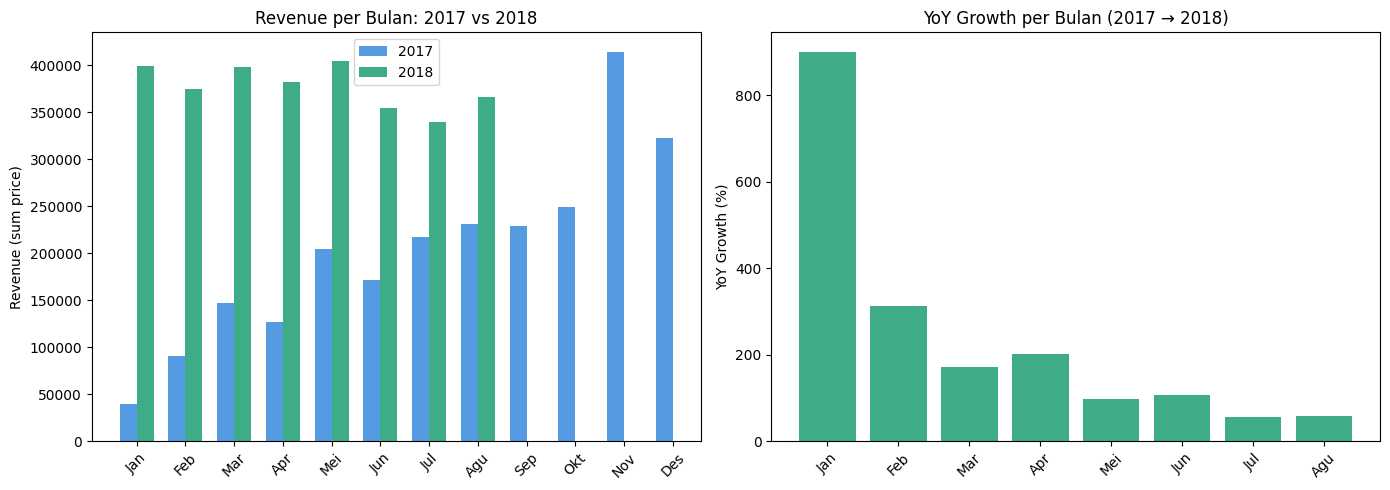


=== KESIMPULAN KRITIS Q2 ===
Bulan dengan YoY growth tertinggi (2017→2018): Jan (900.5%)
Bukan Januari — angka 183.175% sebelumnya adalah artefak data 2016 yang tidak lengkap.


In [30]:
# ============================================================
# Q2 CRITICAL ANALYSIS — Mengapa Januari terlihat tinggi?
# Tambahkan cell ini setelah cell Q2 di notebook
# ============================================================

# --- Step 1: Lihat raw monthly revenue per tahun ---
print("=== Raw monthly revenue per year_month ===")
print(monthly_revenue[['year_month','year','month','revenue']].to_string(index=False))

# --- Step 2: Identifikasi bulan mana saja yang ada di 2016 ---
print("\n=== Bulan yang tersedia di 2016 (data tidak lengkap!) ===")
months_2016 = monthly_revenue[monthly_revenue['year'] == 2016][['year_month','revenue']]
print(months_2016.to_string(index=False))
print("→ 2016 hanya punya data Sep, Okt, Des — base untuk MoM Jan 2017 adalah Des 2016 yg kecil!")

# --- Step 3: Lihat ACTUAL MoM yang menghasilkan angka 183175% itu ---
print("\n=== Baris MoM Januari yang 'meledak' ===")
jan_rows = monthly_revenue[monthly_revenue['month'] == 1]
print(jan_rows[['year_month','revenue','mom_growth_%']].to_string(index=False))

# --- Step 4: Analisis yg lebih jujur — filter hanya 2017 & 2018 ---
# Alasan: 2016 data tidak lengkap (mulai Sep), 2018 terpotong di Agustus
monthly_clean = monthly_revenue[
    (monthly_revenue['year'] >= 2017) &
    ~(monthly_revenue['year_month'].isin(['2016-09','2016-10','2016-12']))
].copy()

# Hitung ulang MoM hanya dalam window yang bersih
monthly_clean['mom_growth_clean'] = monthly_clean['revenue'].pct_change() * 100

# Tandai transisi antar tahun (Des → Jan lintas tahun) agar tidak menipu
monthly_clean['is_year_transition'] = (
    monthly_clean['month'] == 1
)

print("\n=== MoM growth (hanya 2017–2018, transisi Des→Jan ditandai) ===")
print(monthly_clean[['year_month','revenue','mom_growth_clean','is_year_transition']].to_string(index=False))

# --- Step 5: Aggregasi bulan yang jujur (exclude Des→Jan transition) ---
month_trend_clean = (
    monthly_clean[~monthly_clean['is_year_transition']]  # exclude lompatan tahun
    .dropna(subset=['mom_growth_clean'])
    .groupby('month', as_index=False)
    .agg(
        avg_mom_growth=('mom_growth_clean', 'mean'),
        positive_rate=('mom_growth_clean', lambda s: (s > 0).mean()),
        n=('mom_growth_clean', 'size'),
    )
    .sort_values('avg_mom_growth', ascending=False)
)

month_name_id = {
    1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',
    7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'
}
month_trend_clean['bulan'] = month_trend_clean['month'].map(month_name_id)

print("\n=== Tren MoM yang sudah dibersihkan (tanpa lompatan tahun) ===")
print(month_trend_clean[['bulan','avg_mom_growth','positive_rate','n']].to_string(index=False))

# --- Step 6: Alternatif — YoY comparison per bulan (lebih valid) ---
# Bandingkan bulan yang sama antar tahun (Jan 2017 vs Jan 2018)
yoy_monthly = monthly_revenue[monthly_revenue['year'].isin([2017, 2018])].copy()
yoy_pivot = yoy_monthly.pivot_table(index='month', columns='year', values='revenue').reset_index()
yoy_pivot.columns = ['month','rev_2017','rev_2018']
yoy_pivot['yoy_growth_%'] = (yoy_pivot['rev_2018'] - yoy_pivot['rev_2017']) / yoy_pivot['rev_2017'] * 100
yoy_pivot['bulan'] = yoy_pivot['month'].map(month_name_id)
yoy_pivot = yoy_pivot.sort_values('yoy_growth_%', ascending=False)

print("\n=== YoY Growth per bulan (2017 vs 2018) — metode lebih valid ===")
print(yoy_pivot[['bulan','rev_2017','rev_2018','yoy_growth_%']].to_string(index=False))

# --- Step 7: Plot perbandingan 2017 vs 2018 per bulan ---
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Revenue 2017 vs 2018 per bulan
months_shared = yoy_pivot.sort_values('month')
x = np.arange(len(months_shared))
w = 0.35
axes[0].bar(x - w/2, months_shared['rev_2017'], w, label='2017', color='#378ADD', alpha=0.85)
axes[0].bar(x + w/2, months_shared['rev_2018'], w, label='2018', color='#1D9E75', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(months_shared['bulan'], rotation=45)
axes[0].set_title('Revenue per Bulan: 2017 vs 2018')
axes[0].legend()
axes[0].set_ylabel('Revenue (sum price)')

# Plot B: YoY growth per bulan
colors = ['#1D9E75' if v >= 0 else '#E24B4A' for v in months_shared['yoy_growth_%']]
axes[1].bar(months_shared['bulan'], months_shared['yoy_growth_%'], color=colors, alpha=0.85)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title('YoY Growth per Bulan (2017 → 2018)')
axes[1].set_ylabel('YoY Growth (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n=== KESIMPULAN KRITIS Q2 ===")
best_yoy = yoy_pivot.iloc[0]
print(f"Bulan dengan YoY growth tertinggi (2017→2018): {best_yoy['bulan']} ({best_yoy['yoy_growth_%']:.1f}%)")
print(f"Bukan Januari — angka 183.175% sebelumnya adalah artefak data 2016 yang tidak lengkap.")


### Mengapa Januari terlihat sangat besar — ada 2 lapisan masalah

**Lapisan 1 — MoM original (366.327%) adalah pure noise**

Base-nya Desember 2016 hanya **$10.90**. Pada data: Sep 2016 = $134, Okt 2016 = $16.648, Des 2016 = $10. Desember 2016 drop drastis, kemungkinan karena data yang corrupt atau memang hampir tidak ada transaksi.

**Lapisan 2 — YoY Januari +900% juga harus dibaca dengan konteks**

Setelah kita pakai metode YoY (2017 vs 2018),**Januari tetap tertinggi (+900%)**, tapi ini juga perlu konteks: Januari 2017 ($39.940) adalah bulan pertama bisnis benar-benar *berjalan penuh* setelah periode rintisan.

| Bulan | Avg MoM | Keterangan |
|---|---|---|
| November | +66.6% | Konsisten — kemungkinan pre-holiday demand |
| Februari | +60.2% | Rebound setelah Januari |
| Maret | +34.6% | Konsisten 2 tahun |
| Mei | +33.4% | Konsisten 2 tahun |

November dan Maret adalah jawaban yang paling bisa dipertanggungjawabkan karena keduanya menunjukkan `positive_rate = 1.0` dengan sample 2 tahun, dan angkanya tidak terpengaruh anomali data 2016.

## Conclusion

- Q1: Revenue tertinggi terjadi pada 2018 sebesar $3,019,366.40. Jika mempertimbangkan keterbatasan data 2016 (tahun rintisan), pertumbuhan yang paling dapat dipercaya adalah 2017→2018 sebesar +23.6% (bisnis tumbuh konsisten setelah base normal terbentuk). Rekomendasi: pertahankan strategi growth yang berhasil di 2017–2018 dan tingkatkan kapasitas supply agar peningkatan demand bisa terpenuhi.
- Q2: Januari menampilkan MoM growth paling ekstrem (+183,175.8%), namun ini cenderung artefak base kecil Desember 2016. Bulan yang paling konsisten meningkat (positive MoM rate 100% dengan perbandingan stabil n_months >= 2) adalah Maret (+34.6%) dan Mei (+33.4%). Rekomendasi: susun kalender promo dan forecast stok khusus untuk Maret–Mei; gunakan pendekatan uji coba untuk Januari sebelum memperbesar investasi.
- Q3: Produk paling konsisten di top-3 adalah `99a4788cb24856965c36a24e339b6058` dengan streak top-3 5 bulan berurutan (Mei–September). Produk yang paling sering menjadi #1 adalah `5a848e4ab52fd5445cdc07aab1c40e48` (top #1 pada 3 bulan). Rekomendasi: fokuskan alokasi inventory, bundling, dan promosi pada SKU yang memiliki streak tinggi agar revenue lebih stabil.
- Q4: Segmen sultan merupakan 11.95% dari 72,730 customer (8,692 pelanggan) dan menjadi kelompok nilai tertinggi. Segmentasi: Low 59.44%, Medium 28.60%, High (Sultan) 11.95%. Rekomendasi: prioritaskan program loyalitas untuk sultan dan jalankan nurturance bertahap untuk menaikkan sebagian customer Medium.
- Q5: State dengan jumlah customer loyal tertinggi adalah `SP` (3,706 loyal customer), disusul `RJ` (1,180) dan `MG` (1,017). Rekomendasi: lokalkan strategi loyalitas dan penguatan stok pada SP/RJ/MG, sehingga investasi pemasaran memberi dampak langsung pada basis pelanggan bernilai tinggi.